# Date-based analysis — CHIME convolved spectra (AQUATIME)

This notebook performs four linked analyses on the datetime-enriched CHIME convolved CSVs:

| Section | Analysis |
|---------|----------|
| 1 | Load data & compute spectral indices (D², MALH, CHL) |
| 2 | Time series of indices over time |
| 3 | Filter spectra by date range (bloom periods) |
| 4 | Monthly / seasonal aggregation and boxplots |
| 5 | Temporal comparison: raw vs convolved CSV aligned by date |

> **Prerequisites:** run `compare_chime_raw_vs_csv_updated.ipynb` first so that the
> convolved CSVs already contain a `date` column.


In [4]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from phytospec import algorithms as alg, config as cfg

# ── File paths ────────────────────────────────────────────────────────────────
CSV_FILES = {
    "5nm"  : cfg.DATA_RAW / "CHIME" / "AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-5nm-v0.1.csv",
    "10nm" : cfg.DATA_RAW / "CHIME" / "AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-10nm-v0.1.csv",
}

RAW_FILES = {
    "5nm"  : cfg.DATA_RAW / "CHIME" / "chime_05_belgium",
    "10nm" : cfg.DATA_RAW / "CHIME" / "chime_10_belgium",
}

# RT1 reference — needed to add date to raw files for Section 5
RT1_REF_FILE = cfg.DATA_RAW / "belgian_coast_all.csv"

# ── Algorithm parameters ─────────────────────────────────────────────────────
# delta_nm MUST match the actual band spacing of each file
DELTA_NM = {"5nm": 5.0, "10nm": 10.0}

# ── Bloom period definitions (month ranges, inclusive) ────────────────────────
# Adjust to your scientific context
BLOOM_PERIODS = {
    "Phaeocystis (spring)" : (3, 6),   # March – June
    "Diatoms (spring)"     : (2, 5),   # February – May
    "Cyanobacteria (summer)": (6, 9),  # June – September
}

# ── Season mapping ────────────────────────────────────────────────────────────
def month_to_season(m):
    import math
    if m is None or (isinstance(m, float) and math.isnan(m)):
        return np.nan
    return {12:"Winter",1:"Winter",2:"Winter",
            3:"Spring",4:"Spring",5:"Spring",
            6:"Summer",7:"Summer",8:"Summer",
            9:"Autumn",10:"Autumn",11:"Autumn"}.get(int(m), np.nan)

SEASON_ORDER  = ["Winter","Spring","Summer","Autumn"]
MONTH_NAMES   = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]
PALETTE       = {"5nm": "steelblue", "10nm": "tomato"}

print("✓ Configuration loaded")


✓ Configuration loaded


---
## 1. Load data and compute spectral indices

Indices are computed **per spectrum** (loop) using `phytospec.algorithms`.
A `delta_nm` override is required because CHIME band spacing (5 or 10 nm) differs from
the PANTHYR default (2.5 nm), which affects the D² denominator scaling.

In [5]:
def load_csv_with_date(path):
    """Load a convolved CSV and parse the date column."""
    df = pd.read_csv(path, sep=None, engine="python")
    date_cols = [c for c in df.columns if any(k in c.lower() for k in ("date","time"))]
    if date_cols:
        df[date_cols[0]] = pd.to_datetime(df[date_cols[0]], utc=True, errors="coerce")
        df = df.rename(columns={date_cols[0]: "date"})
    return df


def get_spectral_cols(df):
    """Return (wl_array, list_of_col_names) for pure-numeric column names."""
    cols = [c for c in df.columns if re.match(r"^\d+\.?\d*$", str(c))]
    wl   = np.array([float(c) for c in cols])
    return wl, cols


def compute_indices(df, wl, spec_cols, delta_nm):
    """
    Compute D², MALH, CHL and Lubac index per spectrum.
    Returns a DataFrame with one row per spectrum.
    """
    rrs = df[spec_cols].values.astype(float)
    n   = rrs.shape[0]

    d2_vals, malh_vals, chl_vals, lubac_vals = [], [], [], []

    for i in range(n):
        spectrum = pd.Series(rrs[i], index=wl)
        try:
            d2_vals.append(alg.compute_D2(spectrum, delta_nm=delta_nm))
        except Exception:
            d2_vals.append(np.nan)
        try:
            malh_vals.append(alg.compute_MALH(spectrum))
        except Exception:
            malh_vals.append(np.nan)
        try:
            chl_vals.append(alg.compute_CHL(spectrum))
        except Exception:
            chl_vals.append(np.nan)
        try:
            lubac_vals.append(alg.lubac_phaeo_index(spectrum))
        except Exception:
            lubac_vals.append(np.nan)

    meta_cols = [c for c in df.columns if c not in spec_cols]
    result = df[meta_cols].copy().reset_index(drop=True)
    result["D2"]    = d2_vals
    result["MALH"]  = malh_vals
    result["CHL"]   = chl_vals
    result["Lubac"] = lubac_vals
    return result


# ── Load and process both resolutions ─────────────────────────────────────────
datasets = {}   # key -> DataFrame with date + indices

for key, path in CSV_FILES.items():
    if not path.exists():
        print(f"[{key}] File not found: {path}")
        continue

    df = load_csv_with_date(path)
    wl, spec_cols = get_spectral_cols(df)

    print(f"[{key}] {len(df)} spectra | {len(wl)} bands | "
          f"Δλ={DELTA_NM[key]} nm")

    idx_df = compute_indices(df, wl, spec_cols, delta_nm=DELTA_NM[key])

    if "date" in idx_df.columns:
        idx_df["month"]  = idx_df["date"].dt.month
        idx_df["season"] = idx_df["month"].map(month_to_season, na_action="ignore")
        idx_df["year"]   = idx_df["date"].dt.year

    datasets[key] = idx_df
    valid = idx_df["date"].notna().sum() if "date" in idx_df.columns else 0
    print(f"       dates: {valid}/{len(idx_df)} valid | "
          f"D2 nan={idx_df['D2'].isna().sum()} | "
          f"MALH nan={idx_df['MALH'].isna().sum()}")

print("\n✓ Index computation complete")


[5nm] 779 spectra | 120 bands | Δλ=5.0 nm
       dates: 582/779 valid | D2 nan=779 | MALH nan=779
[10nm] 779 spectra | 60 bands | Δλ=10.0 nm
       dates: 582/779 valid | D2 nan=779 | MALH nan=779

✓ Index computation complete


---
## 2. Time series of spectral indices

Each point is one spectrum (one PANTHYR acquisition convolved to CHIME resolution).
Both 5 nm and 10 nm datasets are shown side-by-side.

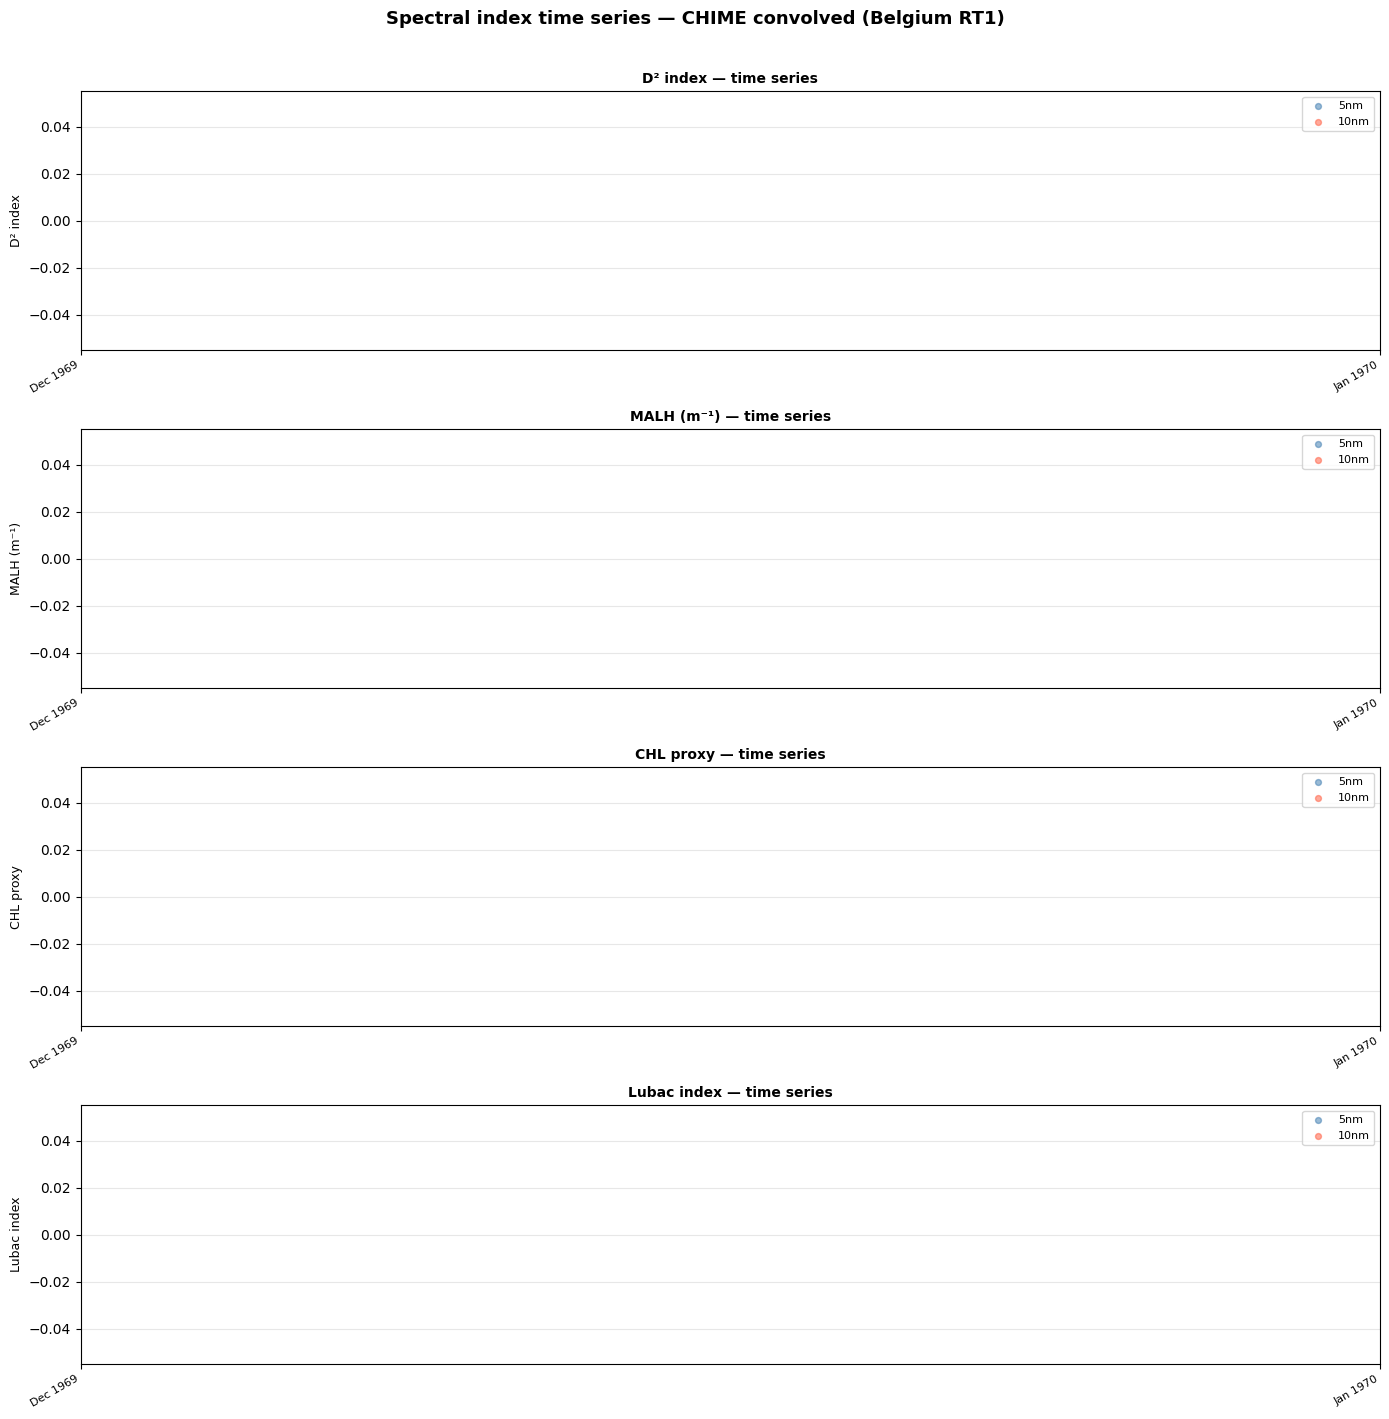

✓ Saved timeseries_indices.png


In [6]:
INDICES = {
    "D2"    : r"D² index",
    "MALH"  : r"MALH (m⁻¹)",
    "CHL"   : r"CHL proxy",
    "Lubac" : r"Lubac index",
}

fig, axes = plt.subplots(len(INDICES), 1, figsize=(14, 3.5 * len(INDICES)),
                         sharex=False)

for ax, (idx_name, idx_label) in zip(axes, INDICES.items()):
    for key, df in datasets.items():
        if "date" not in df.columns:
            continue
        sub = df.dropna(subset=["date", idx_name]).sort_values("date")
        ax.scatter(sub["date"], sub[idx_name],
                   s=18, alpha=0.55, color=PALETTE[key], label=key, zorder=3)
        # 30-day rolling mean
        sub = sub.set_index("date")[idx_name].resample("15D").median()
        ax.plot(sub.index, sub.values, color=PALETTE[key], lw=1.5, alpha=0.8)

    ax.set_ylabel(idx_label, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_title(f"{idx_label} — time series", fontsize=10, fontweight="bold")

plt.suptitle("Spectral index time series — CHIME convolved (Belgium RT1)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("timeseries_indices.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved timeseries_indices.png")


---
## 3. Filter spectra by date range (bloom periods)

Bloom windows are defined in the configuration cell (`BLOOM_PERIODS`).
This section shows the mean spectrum per bloom period and per resolution.

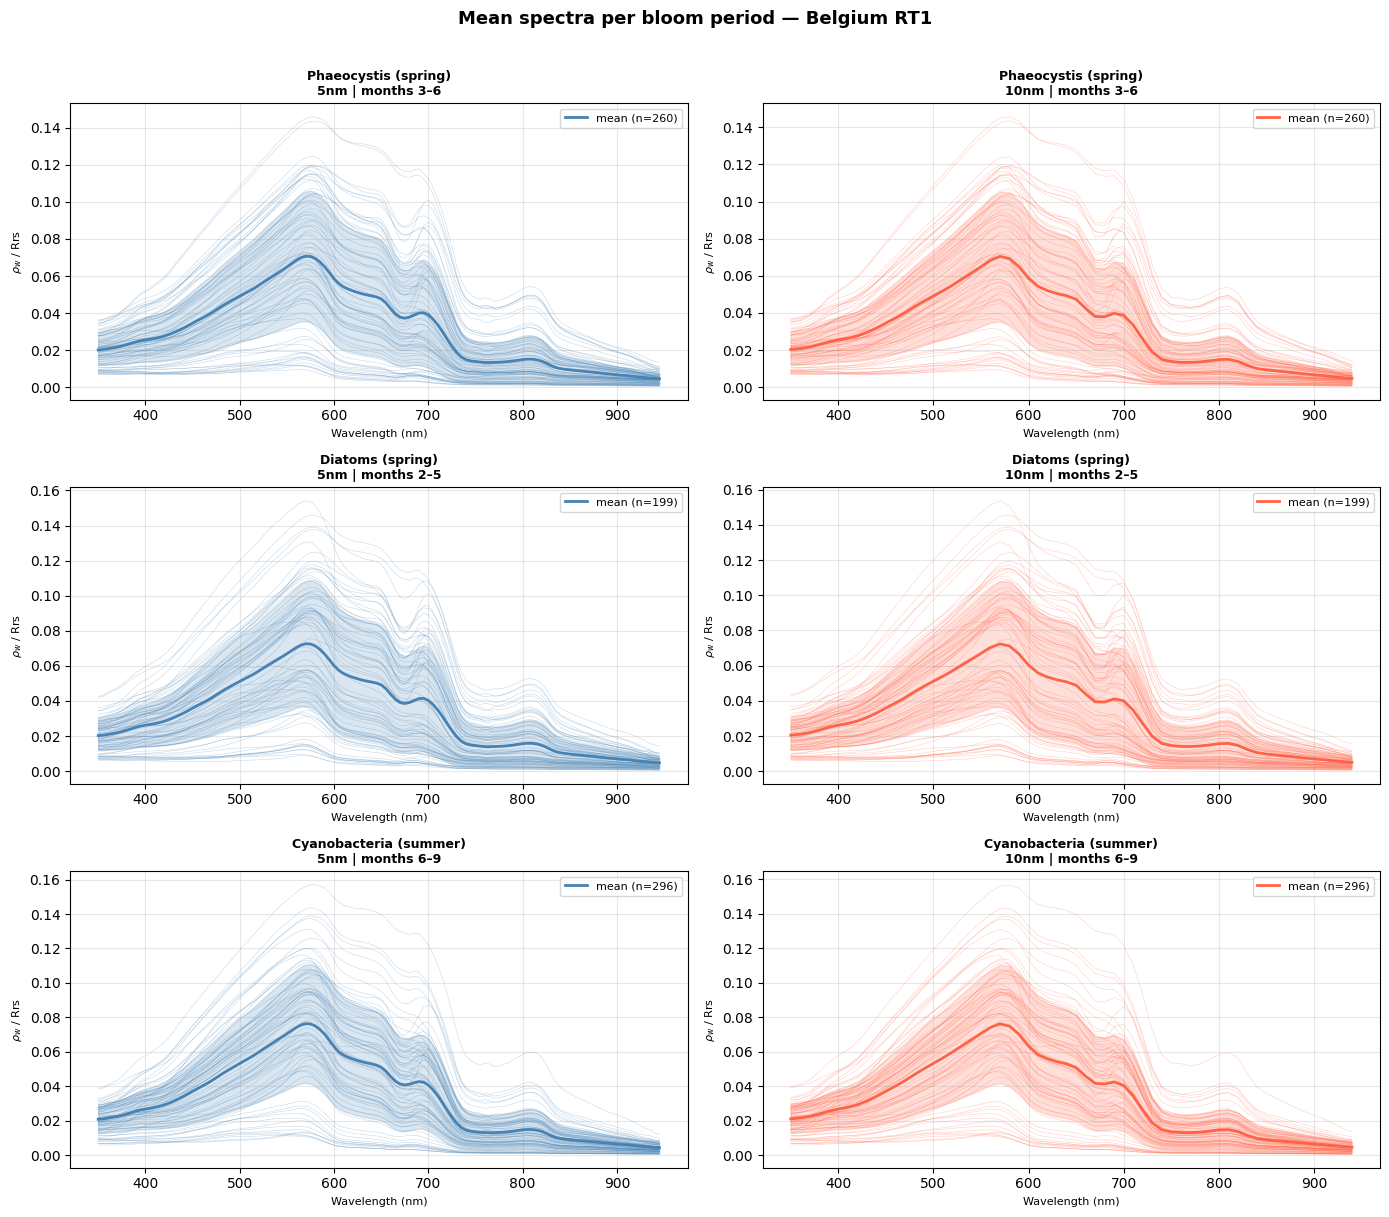

✓ Saved bloom_period_spectra.png


In [7]:
# ── Reload raw spectra for bloom plotting ─────────────────────────────────────
raw_spectra = {}   # key -> (wl, rrs_array, date_series)

for key, path in CSV_FILES.items():
    if not path.exists():
        continue
    df  = load_csv_with_date(path)
    wl, spec_cols = get_spectral_cols(df)
    rrs = df[spec_cols].values.astype(float)
    dates = df["date"] if "date" in df.columns else pd.Series([pd.NaT]*len(df))
    raw_spectra[key] = (wl, rrs, dates.reset_index(drop=True))

n_periods = len(BLOOM_PERIODS)
n_res     = len(raw_spectra)
fig, axes = plt.subplots(n_periods, n_res,
                          figsize=(7 * n_res, 4 * n_periods),
                          sharey=False)
if n_periods == 1: axes = [axes]
if n_res     == 1: axes = [[ax] for ax in axes]

for row, (period_name, (m_start, m_end)) in enumerate(BLOOM_PERIODS.items()):
    for col, key in enumerate(raw_spectra):
        wl, rrs, dates = raw_spectra[key]
        ax = axes[row][col]

        # Filter by month range
        months = dates.dt.month
        if m_start <= m_end:
            mask = (months >= m_start) & (months <= m_end)
        else:   # wraps year-end (e.g. Nov–Feb)
            mask = (months >= m_start) | (months <= m_end)

        rrs_sub = rrs[mask.values]
        n_sub   = rrs_sub.shape[0]

        if n_sub == 0:
            ax.text(0.5, 0.5, "No data in window", ha="center", va="center",
                    transform=ax.transAxes, fontsize=9, color="gray")
        else:
            # Individual spectra (max 80)
            idx_plot = np.linspace(0, n_sub-1, min(n_sub, 80), dtype=int)
            for i in idx_plot:
                ax.plot(wl, rrs_sub[i], lw=0.4, alpha=0.3, color=PALETTE[key])
            # Mean ± std
            mean_ = np.nanmean(rrs_sub, axis=0)
            std_  = np.nanstd(rrs_sub, axis=0)
            ax.plot(wl, mean_, lw=2.0, color=PALETTE[key], label=f"mean (n={n_sub})")
            ax.fill_between(wl, mean_-std_, mean_+std_, alpha=0.2, color=PALETTE[key])

        ax.set_title(f"{period_name}\n{key} | months {m_start}–{m_end}",
                     fontsize=9, fontweight="bold")
        ax.set_xlabel("Wavelength (nm)", fontsize=8)
        ax.set_ylabel(r"$\rho_w$ / Rrs", fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.suptitle("Mean spectra per bloom period — Belgium RT1",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("bloom_period_spectra.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved bloom_period_spectra.png")


---
## 4. Monthly and seasonal aggregation — boxplots

Each index is shown as:
- **(a)** a monthly boxplot (Jan–Dec)
- **(b)** a seasonal boxplot (Winter / Spring / Summer / Autumn)

Both 5 nm and 10 nm resolutions are overlaid using colour.

C:\Users\gvillegas\AppData\Local\Temp\ipykernel_57420\897179485.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Resolution", fontsize=8, title_fontsize=8)
C:\Users\gvillegas\AppData\Local\Temp\ipykernel_57420\897179485.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Resolution", fontsize=8, title_fontsize=8)


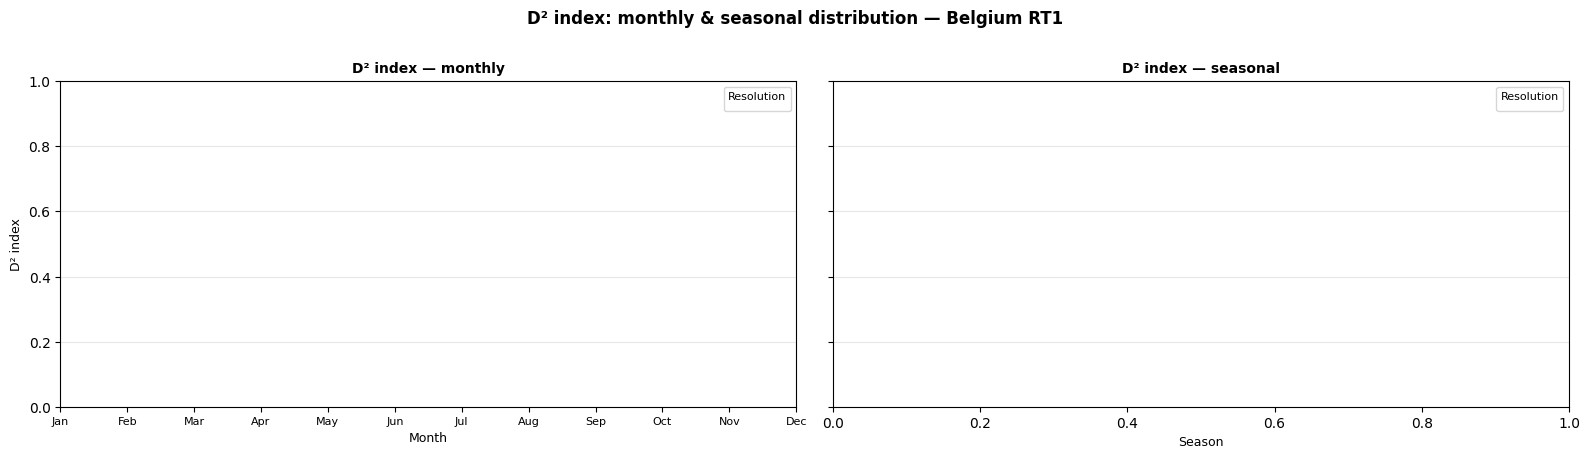

✓ Saved boxplot_D2_monthly_seasonal.png


C:\Users\gvillegas\AppData\Local\Temp\ipykernel_57420\897179485.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Resolution", fontsize=8, title_fontsize=8)
C:\Users\gvillegas\AppData\Local\Temp\ipykernel_57420\897179485.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Resolution", fontsize=8, title_fontsize=8)


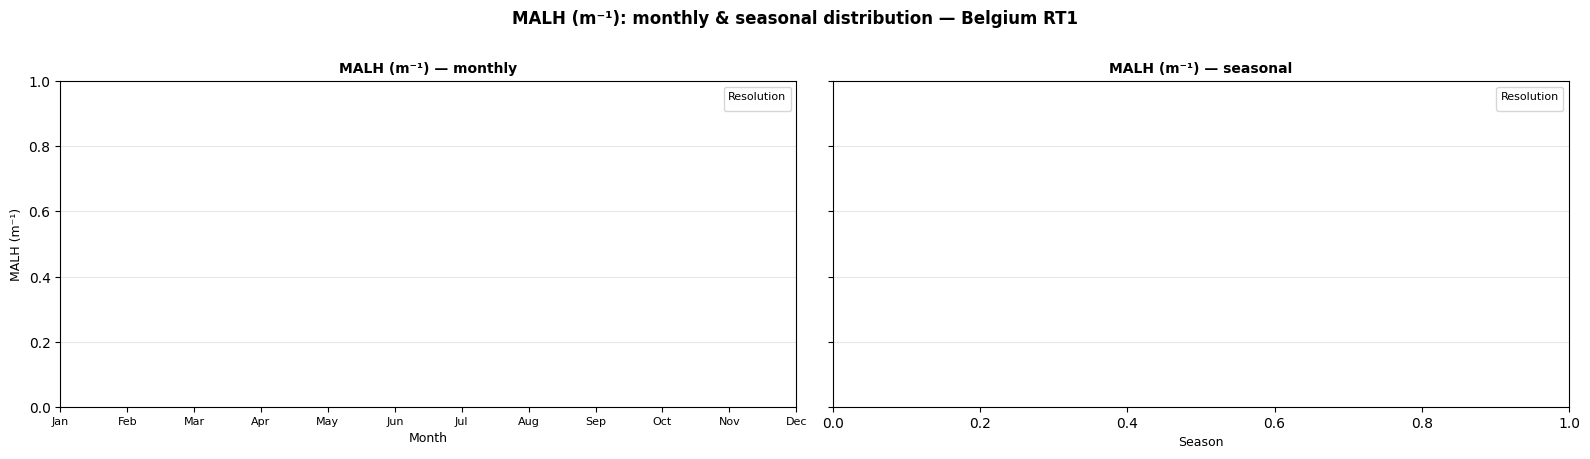

✓ Saved boxplot_MALH_monthly_seasonal.png


C:\Users\gvillegas\AppData\Local\Temp\ipykernel_57420\897179485.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Resolution", fontsize=8, title_fontsize=8)
C:\Users\gvillegas\AppData\Local\Temp\ipykernel_57420\897179485.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Resolution", fontsize=8, title_fontsize=8)


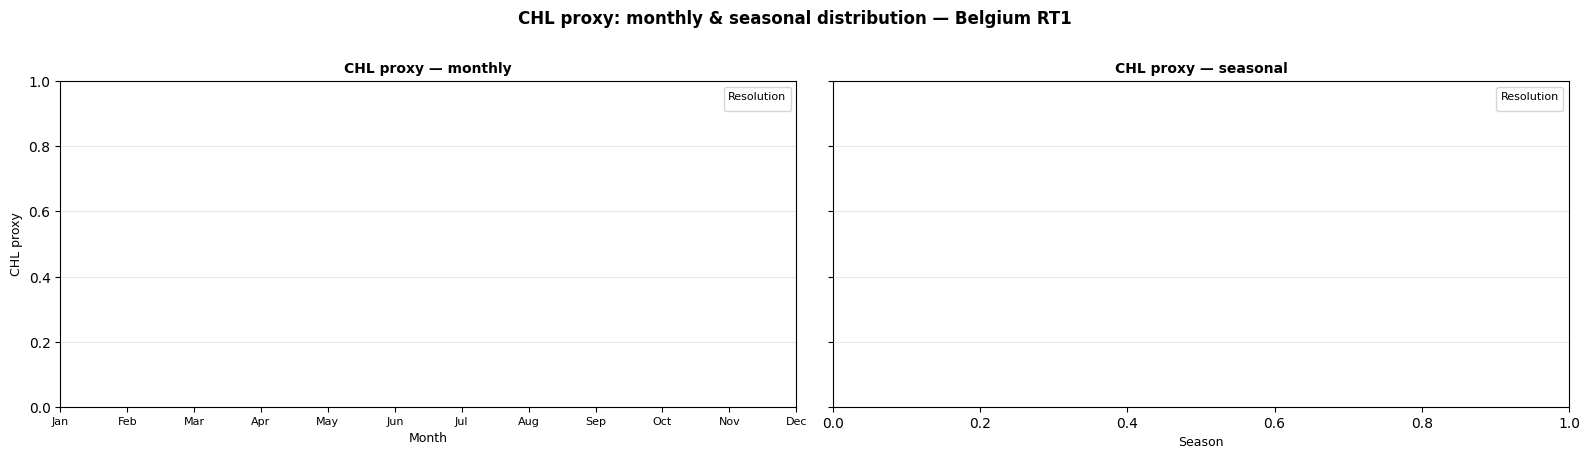

✓ Saved boxplot_CHL_monthly_seasonal.png


C:\Users\gvillegas\AppData\Local\Temp\ipykernel_57420\897179485.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Resolution", fontsize=8, title_fontsize=8)
C:\Users\gvillegas\AppData\Local\Temp\ipykernel_57420\897179485.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Resolution", fontsize=8, title_fontsize=8)


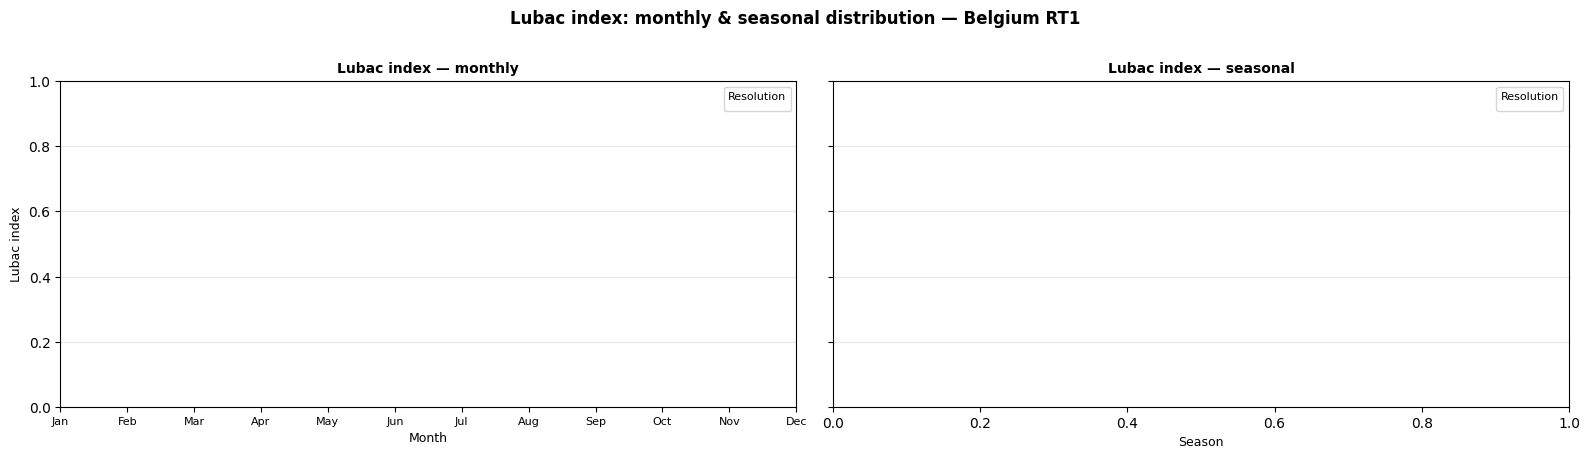

✓ Saved boxplot_Lubac_monthly_seasonal.png


In [8]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Combine datasets with a resolution label
combined = []
for key, df in datasets.items():
    tmp = df.copy()
    tmp["resolution"] = key
    combined.append(tmp)
combined = pd.concat(combined, ignore_index=True)

# ── 4a — Monthly boxplots ─────────────────────────────────────────────────────
for idx_name, idx_label in INDICES.items():
    fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), sharey=True)

    # Monthly
    ax = axes[0]
    sub = combined.dropna(subset=["month", idx_name])
    sns.boxplot(
        data=sub, x="month", y=idx_name, hue="resolution",
        palette=PALETTE, linewidth=0.7, fliersize=2,
        order=list(range(1, 13)), ax=ax
    )
    ax.set_xticks(range(12))
    ax.set_xticklabels(MONTH_NAMES, fontsize=8)
    ax.set_xlabel("Month", fontsize=9)
    ax.set_ylabel(idx_label, fontsize=9)
    ax.set_title(f"{idx_label} — monthly", fontsize=10, fontweight="bold")
    ax.legend(title="Resolution", fontsize=8, title_fontsize=8)
    ax.grid(axis="y", alpha=0.3)

    # Seasonal
    ax = axes[1]
    sub = combined.dropna(subset=["season", idx_name])
    sns.boxplot(
        data=sub, x="season", y=idx_name, hue="resolution",
        palette=PALETTE, linewidth=0.7, fliersize=2,
        order=SEASON_ORDER, ax=ax
    )
    ax.set_xlabel("Season", fontsize=9)
    ax.set_ylabel("", fontsize=9)
    ax.set_title(f"{idx_label} — seasonal", fontsize=10, fontweight="bold")
    ax.legend(title="Resolution", fontsize=8, title_fontsize=8)
    ax.grid(axis="y", alpha=0.3)

    plt.suptitle(f"{idx_label}: monthly & seasonal distribution — Belgium RT1",
                 fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()
    safe = idx_name.replace("²", "2")
    fname = f"boxplot_{safe}_monthly_seasonal.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved {fname}")


### 4c. Monthly statistics summary table

In [13]:
for key, df in datasets.items():
    print(f"\n{'='*60}\n Resolution: {key}\n{'='*60}")
    if "month" not in df.columns:
        print("  No date column — cannot compute monthly stats")
        continue
    stats = (
        df.groupby("month")[["D2","MALH","CHL","Lubac"]]
          .agg(["median","std","count"])
    )
    stats.index = [MONTH_NAMES[int(m)-1] if not pd.isna(m) else "Unknown" for m in stats.index]
    display(stats.round(5))



 Resolution: 5nm


D2             MALH              CHL            Lubac          
    median std count median std count median std count median std count
Jan    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Feb    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Mar    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Apr    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
May    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Jun    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Jul    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Aug    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Sep    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Oct    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Nov    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Dec    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0


 Resolution: 10nm


D2             MALH              CHL            Lubac          
    median std count median std count median std count median std count
Jan    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Feb    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Mar    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Apr    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
May    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Jun    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Jul    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Aug    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Sep    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Oct    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Nov    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0
Dec    NaN NaN     0    NaN NaN     0    NaN NaN     0    NaN NaN     0

---
## 5. Temporal comparison: raw vs convolved CSV aligned by date

The raw files (`chime_05_belgium`, `chime_10_belgium`) share the same `icase` ordering
as the convolved CSVs.  This section aligns them by date and compares:
- spectral index values computed from raw vs convolved spectra
- a scatter plot (raw vs CSV) per index, coloured by month

In [10]:
# ── Build icase -> date lookup from RT1 reference ─────────────────────────────
icase_to_dt = {}
if RT1_REF_FILE.exists():
    ref = pd.read_csv(RT1_REF_FILE, sep=None, engine="python")
    dt_col_cands = [c for c in ref.columns
                    if any(k in c.lower() for k in ("datetime","date","time"))]
    if dt_col_cands:
        dt_col = dt_col_cands[0]
        ref[dt_col] = pd.to_datetime(ref[dt_col], utc=True, errors="coerce")
        if "name" in ref.columns:
            ref = ref[ref["name"] == "RT1"].copy()
        ref = ref.reset_index(drop=True)
        icase_to_dt = ref[dt_col].to_dict()
        print(f"✓ icase->date lookup built: {len(icase_to_dt)} entries")
    else:
        print("WARNING: no datetime column in RT1 reference")
else:
    print(f"WARNING: {RT1_REF_FILE} not found — Section 5 will be skipped")

# ── Load and index raw files ──────────────────────────────────────────────────
raw_datasets = {}   # key -> DataFrame with date + indices (same structure as datasets)

for key, path in RAW_FILES.items():
    if not path.exists():
        print(f"[{key}] raw file not found: {path}")
        continue

    df_raw = pd.read_csv(path, sep=None, engine="python")
    wl_raw, spec_cols_raw = get_spectral_cols(df_raw)

    if icase_to_dt and "icase" in df_raw.columns:
        df_raw["date"] = df_raw["icase"].map(icase_to_dt)
        df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True, errors="coerce")

    idx_raw = compute_indices(df_raw, wl_raw, spec_cols_raw, delta_nm=DELTA_NM[key])

    if "date" in idx_raw.columns:
        idx_raw["month"]  = idx_raw["date"].dt.month
        idx_raw["season"] = idx_raw["month"].map(month_to_season, na_action="ignore")

    raw_datasets[key] = idx_raw
    print(f"[{key}] raw: {len(idx_raw)} spectra | "
          f"date coverage: {idx_raw['date'].notna().sum()} rows")


✓ icase->date lookup built: 582 entries
[5nm] raw: 779 spectra | date coverage: 582 rows
[10nm] raw: 779 spectra | date coverage: 582 rows


C:\Users\gvillegas\AppData\Local\Temp\ipykernel_57420\2499160876.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_raw["date"] = df_raw["icase"].map(icase_to_dt)


### 5a. Time series overlay: raw vs convolved

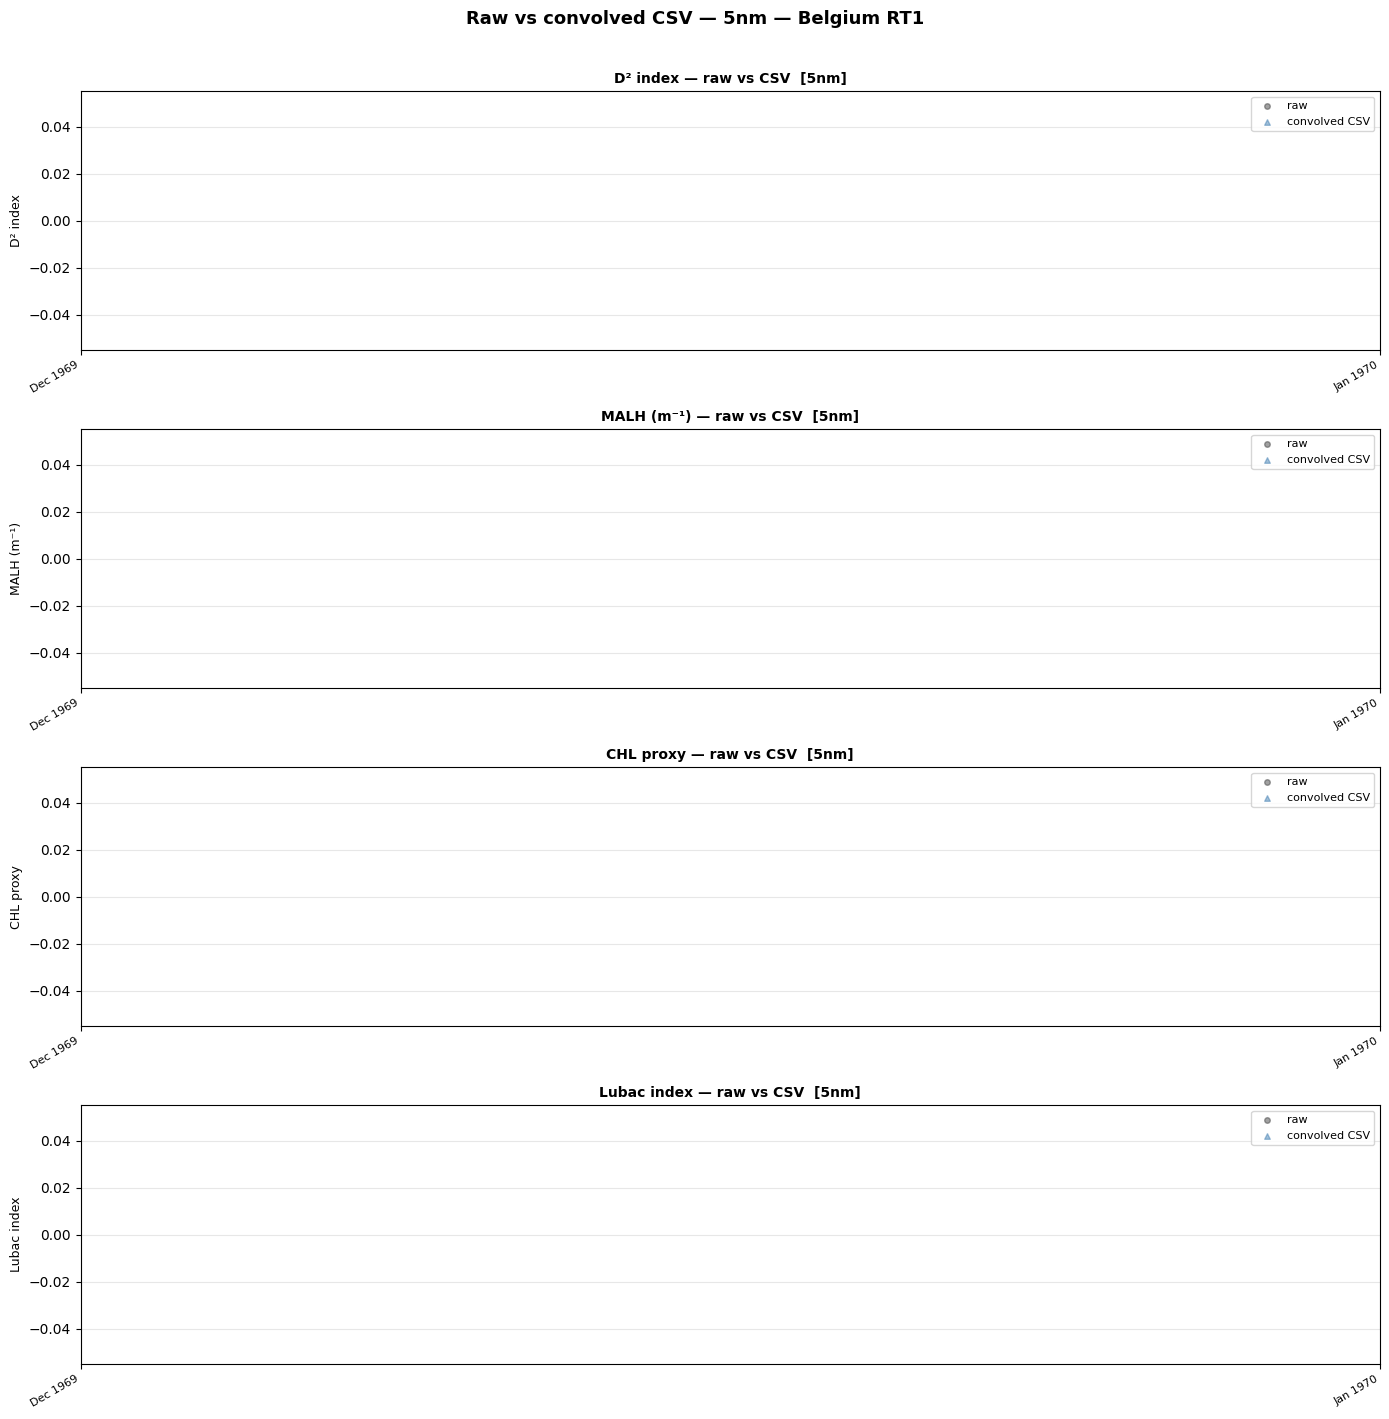

✓ Saved raw_vs_csv_timeseries_5nm.png


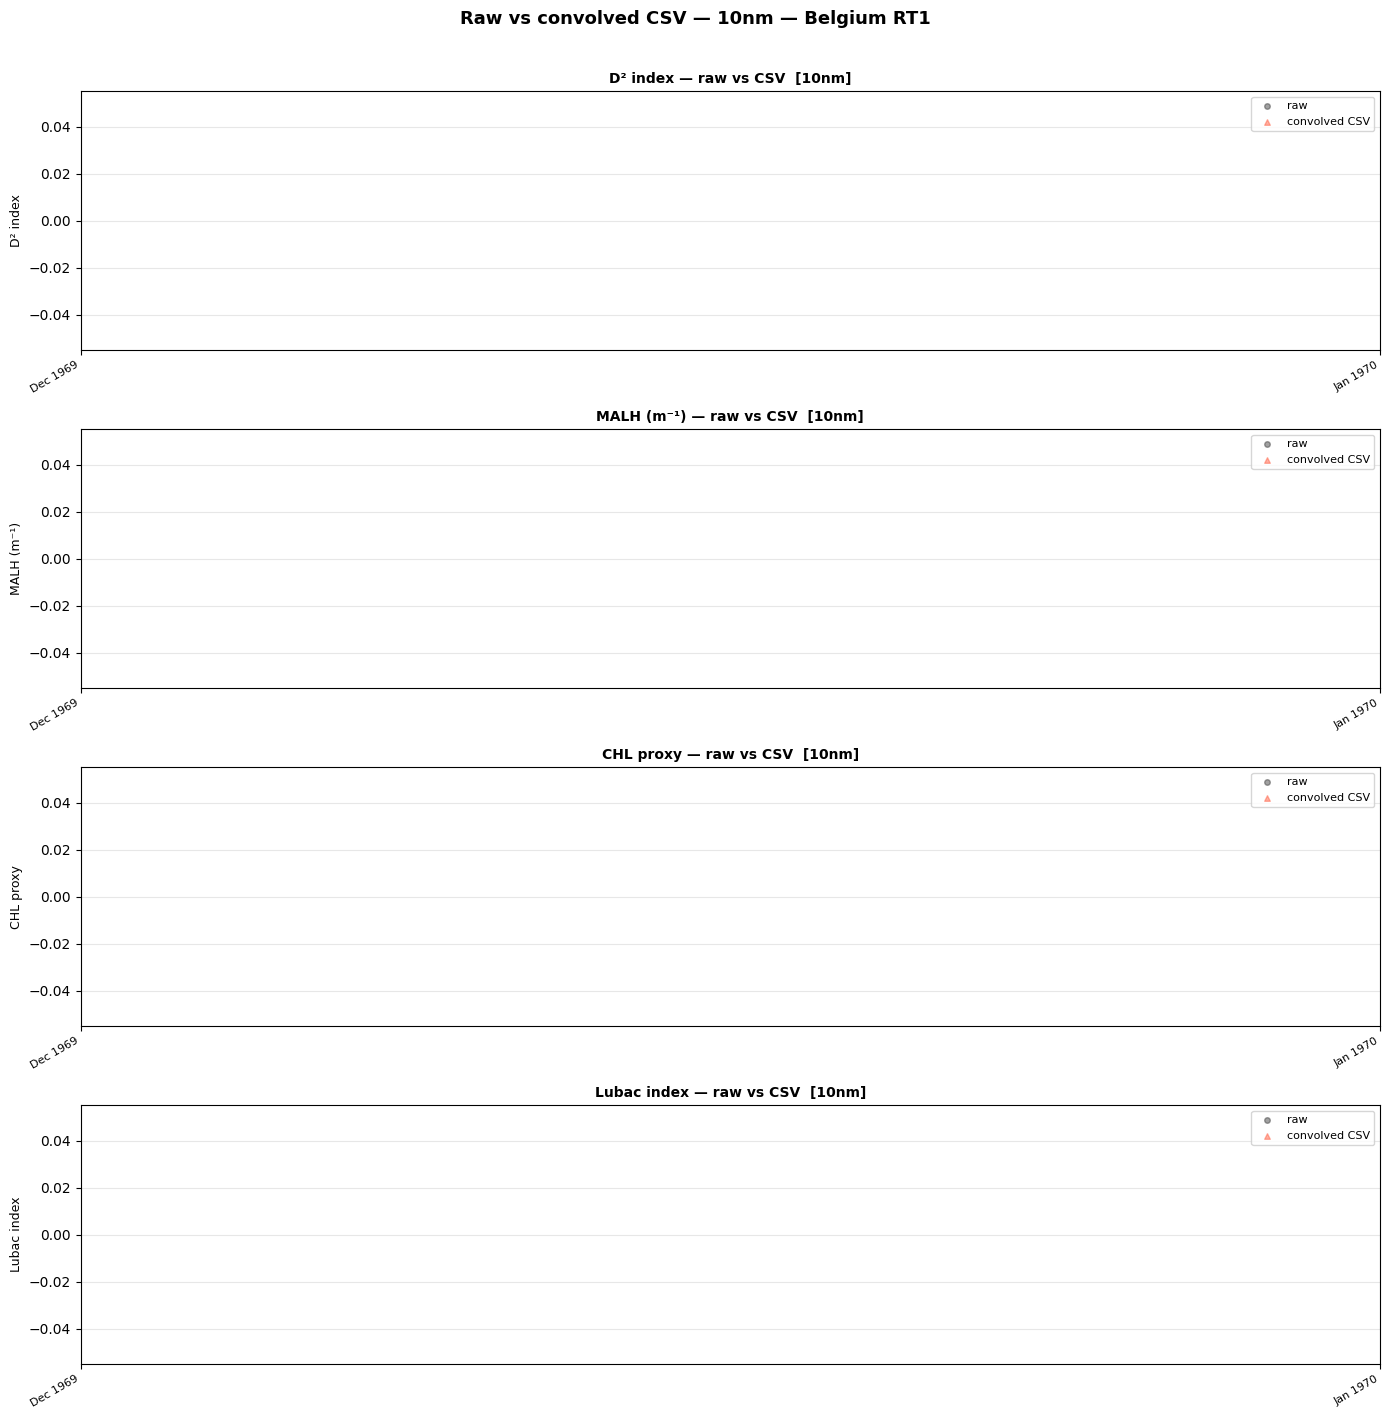

✓ Saved raw_vs_csv_timeseries_10nm.png


In [11]:
COMPARE_INDICES = ["D2", "MALH", "CHL", "Lubac"]

for key in datasets:
    if key not in raw_datasets:
        continue
    df_csv = datasets[key]
    df_raw = raw_datasets[key]

    fig, axes = plt.subplots(len(COMPARE_INDICES), 1,
                              figsize=(14, 3.5 * len(COMPARE_INDICES)),
                              sharex=False)

    for ax, idx_name in zip(axes, COMPARE_INDICES):
        idx_label = INDICES[idx_name]

        for src, df, marker, ls, label in [
            ("raw", df_raw, "o", "-",  "raw"),
            ("csv", df_csv, "^", "--", "convolved CSV"),
        ]:
            if "date" not in df.columns:
                continue
            sub = df.dropna(subset=["date", idx_name]).sort_values("date")
            color = PALETTE[key] if src == "csv" else "#444444"
            ax.scatter(sub["date"], sub[idx_name],
                       s=16, alpha=0.5, color=color, marker=marker,
                       label=label, zorder=3)
            roll = sub.set_index("date")[idx_name].resample("15D").median()
            ax.plot(roll.index, roll.values, color=color, lw=1.4, ls=ls)

        ax.set_ylabel(idx_label, fontsize=9)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc="upper right")
        ax.set_title(f"{idx_label} — raw vs CSV  [{key}]",
                     fontsize=10, fontweight="bold")

    plt.suptitle(f"Raw vs convolved CSV — {key} — Belgium RT1",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    fname = f"raw_vs_csv_timeseries_{key}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved {fname}")


### 5b. Scatter: raw index vs CSV index (coloured by month)

C:\Users\gvillegas\AppData\Local\Temp\ipykernel_57420\4128627694.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("hsv", 12)


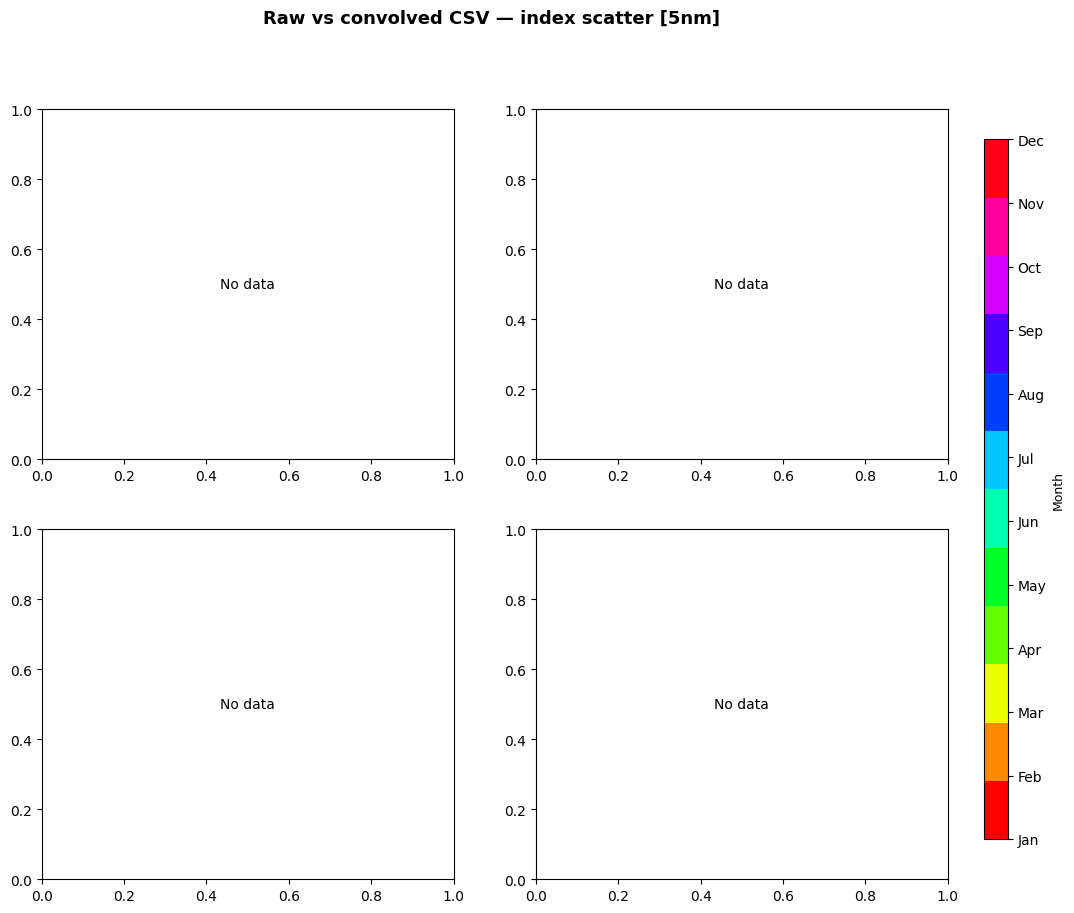

✓ Saved scatter_raw_vs_csv_5nm.png


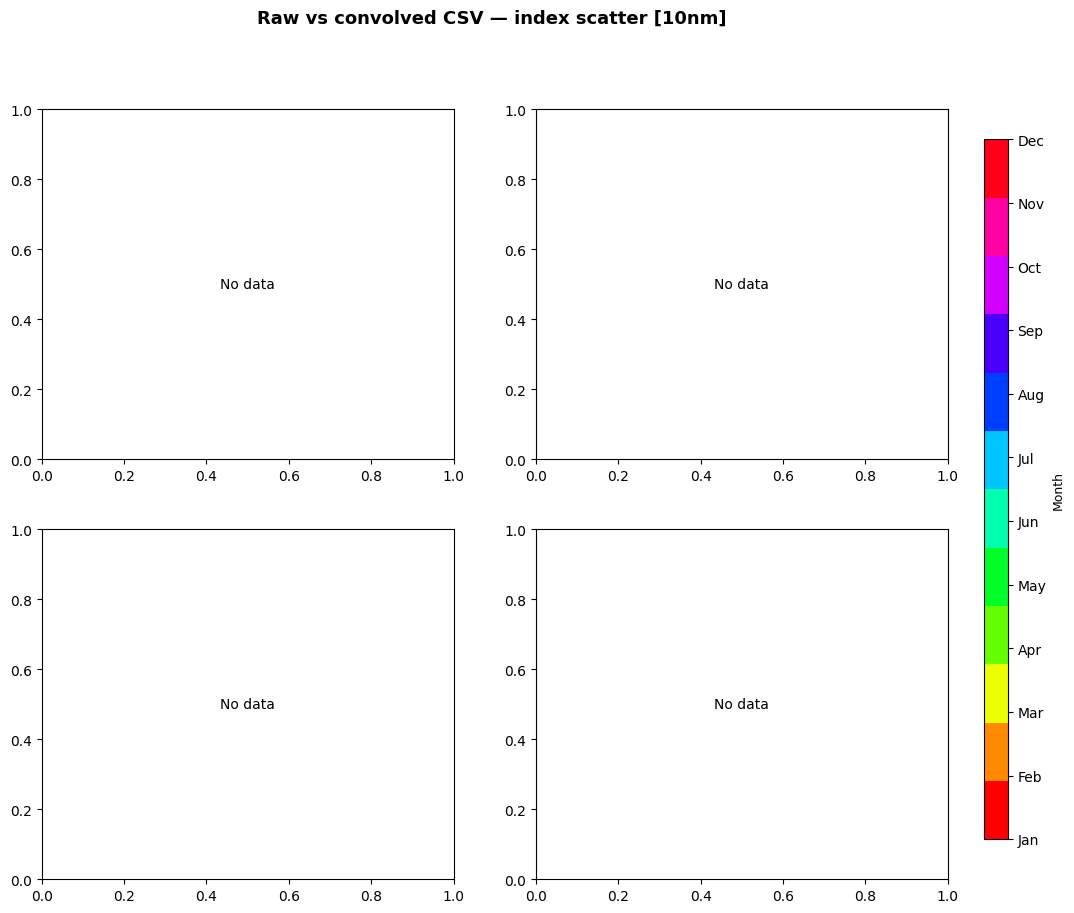

✓ Saved scatter_raw_vs_csv_10nm.png


In [12]:
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase

cmap = get_cmap("hsv", 12)
norm = Normalize(vmin=1, vmax=12)

for key in datasets:
    if key not in raw_datasets:
        continue

    df_csv = datasets[key]
    df_raw = raw_datasets[key]

    # Align on icase
    if "icase" not in df_csv.columns or "icase" not in df_raw.columns:
        print(f"[{key}] Missing 'icase' — cannot align for scatter")
        continue

    merged = df_csv.merge(df_raw, on="icase", suffixes=("_csv", "_raw"))

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for ax, idx_name in zip(axes, COMPARE_INDICES):
        xcol = f"{idx_name}_csv"
        ycol = f"{idx_name}_raw"
        month_col = "month_csv" if "month_csv" in merged.columns else "month_raw"

        sub = merged.dropna(subset=[xcol, ycol])
        if sub.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes)
            continue

        months = sub[month_col].values if month_col in sub.columns else np.ones(len(sub))
        sc = ax.scatter(sub[xcol], sub[ycol],
                        c=months, cmap=cmap, norm=norm,
                        s=25, alpha=0.65, edgecolors="none")

        # 1:1 line
        lo = min(sub[xcol].min(), sub[ycol].min())
        hi = max(sub[xcol].max(), sub[ycol].max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, label="1:1")

        # R²
        r  = np.corrcoef(sub[xcol], sub[ycol])[0, 1]
        ax.text(0.05, 0.93, f"r = {r:.3f}", transform=ax.transAxes,
                fontsize=9, va="top")

        ax.set_xlabel(f"{INDICES[idx_name]} (convolved CSV)", fontsize=9)
        ax.set_ylabel(f"{INDICES[idx_name]} (raw)", fontsize=9)
        ax.set_title(idx_name, fontsize=10, fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    # Shared colorbar for months
    fig.subplots_adjust(right=0.88)
    cax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
    cb  = ColorbarBase(cax, cmap=cmap, norm=norm, orientation="vertical")
    cb.set_ticks(range(1, 13))
    cb.set_ticklabels(MONTH_NAMES)
    cb.set_label("Month", fontsize=9)

    plt.suptitle(f"Raw vs convolved CSV — index scatter [{key}]",
                 fontsize=13, fontweight="bold")
    fname = f"scatter_raw_vs_csv_{key}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved {fname}")


## Diagnmostic

In [14]:
# Diagnostic: run indices on one spectrum and print any error
_key = list(CSV_FILES.keys())[0]
_df  = load_csv_with_date(CSV_FILES[_key])
_wl, _cols = get_spectral_cols(_df)
_spectrum  = pd.Series(_df[_cols].values[0].astype(float), index=_wl)
print("Index dtype:", _spectrum.index.dtype, "| first 5:", _spectrum.index[:5].tolist())
for fn_name, fn in [("D2",   lambda s: alg.compute_D2(s, delta_nm=DELTA_NM[_key])),
                    ("MALH", alg.compute_MALH),
                    ("CHL",  alg.compute_CHL),
                    ("Lubac",alg.lubac_phaeo_index)]:
    try:
        print(f"  {fn_name}: {fn(_spectrum)}")
    except Exception as e:
        print(f"  {fn_name} ERROR: {type(e).__name__}: {e}")

Index dtype: float64 | first 5: [350.0, 355.0, 360.0, 365.0, 370.0]
  D2 ERROR: TypeError: compute_D2() got an unexpected keyword argument 'delta_nm'
  MALH ERROR: TypeError: compute_MALH() missing 1 required positional argument: 'wl'
  CHL ERROR: TypeError: compute_CHL() missing 1 required positional argument: 'wl'
  Lubac ERROR: TypeError: lubac_phaeo_index() missing 1 required positional argument: 'd2r'
